# Optimizing Pittsburgh's Public Works Through Predictive Modeling

### Jon Hellner, Farrukh Masood, Pallavi Rajan


### Table of Contents
1. [Data Cleaning and Exploratory Data Analysis](#data-cleaning-and-exploratory-data-analysis)
2. [Component 1: Geospatial Complaint Hotspot Clustering](#component-1-geospatial-complaint-hotspot-clustering)
3. [Component 2: Repeat Complaint Zone Modeling for Focused Intervention](#component-2-repeat-complaint-zone-modeling-for-focused-intervention)
4. [Component 3: Forecasting Departmental Workload for Resource Allocation](#component-3-forecasting-departmental-workload-for-resource-allocation)


### Data Cleaning and Exploratory Data Analysis

In [2]:
import pandas as pd
# Replace 'your_file.csv' with the path to your CSV file
df = pd.read_csv('311data.csv')

# Display the first few rows of the DataFrame
df.head()

,_id,group_id,num_requests,parent_closed,status_name,status_code,dept,request_type_name,request_type_id,create_date_et,...,cross_street_id,city,neighborhood,census_tract,council_district,ward,police_zone,latitude,longitude,geo_accuracy
0,1,827262,1,f,open,0,DPW - Administration,Park Shelter,543,2024-03-12T10:50:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
1,2,720661,1,f,open,0,DPW - Administration,Park Shelter,543,2023-03-20T07:52:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
2,3,722010,1,f,open,0,DPW - Administration,Park Shelter,543,2023-03-24T07:44:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
3,4,846915,1,f,open,0,Police - Zones 1-6,Illegal Parking,417,2024-05-19T12:24:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
4,5,853708,1,f,open,0,DPW - Facilities,City Facility,375,2024-06-06T23:04:00,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES


In [3]:
# 1. View first and last few rows
print("First 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

# 2. Basic info about dataset
print("\nDataFrame Info:")
print(df.info())

# 3. Summary statistics for numeric columns
print("\nSummary Statistics:")
print(df.describe())

# 4. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 5. Check data types
print("\nData Types:")
print(df.dtypes)

# 6. Check for duplicates
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# 7. Check unique values in each column
print("\nUnique Values per Column:")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")


First 5 rows:
   _id  group_id  num_requests parent_closed status_name  status_code  \
0    1    827262             1             f        open            0   
1    2    720661             1             f        open            0   
2    3    722010             1             f        open            0   
3    4    846915             1             f        open            0   
4    5    853708             1             f        open            0   

                   dept request_type_name  request_type_id  \
0  DPW - Administration      Park Shelter              543   
1  DPW - Administration      Park Shelter              543   
2  DPW - Administration      Park Shelter              543   
3    Police - Zones 1-6   Illegal Parking              417   
4      DPW - Facilities     City Facility              375   

        create_date_et  ... cross_street_id        city neighborhood  \
0  2024-03-12T10:50:00  ...             NaN  Pittsburgh          NaN   
1  2023-03-20T07:52:00  ...   

In [4]:
# 8. Correlation matrix (for numerical features)
print("\nCorrelation Matrix:")
df.corr(numeric_only=True)


Correlation Matrix:


,_id,group_id,num_requests,status_code,request_type_id,street_id,cross_street_id,census_tract,council_district,ward,police_zone,latitude,longitude
_id,1.000000,0.441257,-0.010049,-0.170977,-0.005905,0.054392,0.013294,0.038791,-0.099829,0.144437,0.140179,0.088449,-0.091065
group_id,0.441257,1.000000,-0.021469,-0.067091,0.148791,0.053319,-0.010486,-0.014291,-0.035190,-0.006676,-0.009653,0.034523,-0.034792
num_requests,-0.010049,-0.021469,1.000000,0.013188,-0.005950,-0.006233,0.001935,0.009683,-0.006438,0.016536,0.007076,0.005472,-0.005713
status_code,-0.170977,-0.067091,0.013188,1.000000,-0.086965,-0.003547,-0.043875,0.006318,0.002484,0.014957,0.000060,0.009715,-0.009600
request_type_id,-0.005905,0.148791,-0.005950,-0.086965,1.000000,0.024845,0.001050,0.001887,0.010302,-0.040723,-0.011167,0.015030,-0.014934
street_id,0.054392,0.053319,-0.006233,-0.003547,0.024845,1.000000,0.006191,0.072123,-0.025517,0.021991,-0.002684,0.123877,-0.123826
cross_street_id,0.013294,-0.010486,0.001935,-0.043875,0.001050,0.006191,1.000000,0.006154,0.035927,-0.033332,0.000511,0.031539,-0.031132
census_tract,0.038791,-0.014291,0.009683,0.006318,0.001887,0.072123,0.006154,1.000000,-0.377255,0.458636,0.016557,-0.157214,-0.295675
council_district,-0.099829,-0.035190,-0.006438,0.002484,0.010302,-0.025517,0.035927,-0.377255,1.000000,-0.578934,0.291711,0.255188,0.749714
ward,0.144437,-0.006676,0.016536,0.014957,-0.040723,0.021991,-0.033332,0.458636,-0.578934,1.000000,-0.117779,-0.332024,-0.495850


In [5]:
# 9. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum()/len(df))



Missing Values:
_id                  0.000000
group_id             0.000000
num_requests         0.000000
parent_closed        0.000000
status_name          0.000000
status_code          0.000000
dept                 0.005179
request_type_name    0.000000
request_type_id      0.000000
create_date_et       0.000000
create_date_utc      0.000000
last_action_et       0.000000
last_action_utc      0.000000
closed_date_et       0.114467
closed_date_utc      0.114467
origin               0.000000
street               0.386531
cross_street         0.874335
street_id            0.378511
cross_street_id      0.378511
city                 0.000000
neighborhood         0.045832
census_tract         0.280031
council_district     0.044054
ward                 0.045625
police_zone          0.045947
latitude             0.038518
longitude            0.038518
geo_accuracy         0.000000
dtype: float64


In [6]:
df.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'dept', 'request_type_name', 'request_type_id',
       'create_date_et', 'create_date_utc', 'last_action_et',
       'last_action_utc', 'closed_date_et', 'closed_date_utc', 'origin',
       'street', 'cross_street', 'street_id', 'cross_street_id', 'city',
       'neighborhood', 'census_tract', 'council_district', 'ward',
       'police_zone', 'latitude', 'longitude', 'geo_accuracy'],
      dtype='object')

In [7]:
df = df.drop(columns=['census_tract', 'cross_street'])

In [8]:
df_ML1 = df[[ 'group_id', 'num_requests', 'status_code', 'dept','request_type_name', 'street','cross_street_id', 'neighborhood', 'police_zone','council_district' ,'geo_accuracy','latitude','longitude','create_date_et']]
df_ML1

#latitude, longitude, request_type_name, num_requests,Month/Season from create_date_et.

,group_id,num_requests,status_code,dept,request_type_name,street,cross_street_id,neighborhood,police_zone,council_district,geo_accuracy,latitude,longitude,create_date_et
0,827262,1,0,DPW - Administration,Park Shelter,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES,NaN,NaN,2024-03-12T10:50:00
1,720661,1,0,DPW - Administration,Park Shelter,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES,NaN,NaN,2023-03-20T07:52:00
2,722010,1,0,DPW - Administration,Park Shelter,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES,NaN,NaN,2023-03-24T07:44:00
3,846915,1,0,Police - Zones 1-6,Illegal Parking,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES,NaN,NaN,2024-05-19T12:24:00
4,853708,1,0,DPW - Facilities,City Facility,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES,NaN,NaN,2024-06-06T23:04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815412,926085,1,0,DPW - Street Maintenance,"Litter, Public Property",BAILEY AVE,0.0,Mount Washington,3.0,3.0,EXACT,40.426746,-80.002860,2025-02-03T13:49:00
815413,926006,1,1,Pittsburgh Water and Sewer Authority,Water Main Break,HARWOOD ST,0.0,Mount Washington,3.0,3.0,EXACT,40.424838,-80.003941,2025-02-02T10:59:00
815414,925993,1,1,DOMI - Structures,Water Main Break,HARWOOD ST,0.0,Mount Washington,3.0,3.0,EXACT,40.425032,-80.003939,2025-02-02T08:43:00
815415,926118,1,0,Police - Zones 1-6,Illegal Parking,NaN,NaN,East Liberty,5.0,9.0,APPROXIMATE,40.460578,-79.927670,2025-03-04T12:17:00


In [9]:
df_ML1 = df_ML1[df_ML1['request_type_name'] == 'Potholes']
print(df_ML1.isnull().sum()/len(df_ML1))
df_ML1

group_id             0.000000
num_requests         0.000000
status_code          0.000000
dept                 0.000000
request_type_name    0.000000
street               0.011170
cross_street_id      0.001052
neighborhood         0.013837
police_zone          0.014074
council_district     0.012118
geo_accuracy         0.000000
latitude             0.001037
longitude            0.001037
create_date_et       0.000000
dtype: float64


,group_id,num_requests,status_code,dept,request_type_name,street,cross_street_id,neighborhood,police_zone,council_district,geo_accuracy,latitude,longitude,create_date_et
1710,846236,1,0,DPW - Street Maintenance,Potholes,10TH ST BRG,0.0,NaN,NaN,3.0,EXACT,40.432324,-79.989090,2024-05-16T15:31:00
2309,584992,1,3,DPW - Street Maintenance,Potholes,JACKSON ST,0.0,Highland Park,5.0,7.0,EXACT,40.471798,-79.922279,2021-12-05T09:31:00
2414,718917,1,0,DPW - Street Maintenance,Potholes,LIBERTY AVE,32.0,Strip District,2.0,7.0,EXACT,40.459226,-79.970696,2023-03-13T08:07:00
2467,666491,1,3,DPW - Street Maintenance,Potholes,MELLON ST,0.0,Highland Park,5.0,7.0,EXACT,40.475381,-79.922528,2022-08-10T19:55:00
2473,668287,1,3,DPW - Street Maintenance,Potholes,MELLON ST,0.0,Highland Park,5.0,7.0,EXACT,40.475239,-79.922703,2022-08-16T11:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815374,926083,1,0,DPW - Street Maintenance,Potholes,N ST CLAIR ST,0.0,East Liberty,5.0,9.0,EXACT,40.463790,-79.928211,2025-02-03T13:45:00
815386,925884,1,0,DPW - Street Maintenance,Potholes,MEREDITH ST,0.0,Carrick,3.0,4.0,EXACT,40.397795,-79.984652,2025-02-01T10:10:00
815390,925967,1,0,DPW - Street Maintenance,Potholes,Brownwood Ave,0.0,New Homestead,4.0,5.0,EXACT,40.394031,-79.920844,2025-02-01T17:27:00
815392,925883,1,1,DPW - Street Maintenance,Potholes,HOLT ST,0.0,South Side Slopes,3.0,3.0,EXACT,40.422040,-79.973212,2025-02-01T10:09:00


In [10]:
df_ML1['street'].value_counts()

street
FIFTH AVE        879
PENN AVE         851
LIBERTY AVE      652
FORBES AVE       611
CENTRE AVE       602
                ... 
KIMBOL ST          1
Broadmoor Ave      1
LAWTON AVE         1
ATKINS ST          1
Brownwood Ave      1
Name: count, Length: 4500, dtype: int64

In [11]:
df_ML1_cleaned_R1 = df_ML1.dropna()
df_ML1_cleaned_R1 

,group_id,num_requests,status_code,dept,request_type_name,street,cross_street_id,neighborhood,police_zone,council_district,geo_accuracy,latitude,longitude,create_date_et
2309,584992,1,3,DPW - Street Maintenance,Potholes,JACKSON ST,0.0,Highland Park,5.0,7.0,EXACT,40.471798,-79.922279,2021-12-05T09:31:00
2414,718917,1,0,DPW - Street Maintenance,Potholes,LIBERTY AVE,32.0,Strip District,2.0,7.0,EXACT,40.459226,-79.970696,2023-03-13T08:07:00
2467,666491,1,3,DPW - Street Maintenance,Potholes,MELLON ST,0.0,Highland Park,5.0,7.0,EXACT,40.475381,-79.922528,2022-08-10T19:55:00
2473,668287,1,3,DPW - Street Maintenance,Potholes,MELLON ST,0.0,Highland Park,5.0,7.0,EXACT,40.475239,-79.922703,2022-08-16T11:02:00
2793,584969,1,3,DPW - Street Maintenance,Potholes,N ST CLAIR ST,0.0,Highland Park,5.0,7.0,EXACT,40.472900,-79.922700,2021-12-04T16:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815374,926083,1,0,DPW - Street Maintenance,Potholes,N ST CLAIR ST,0.0,East Liberty,5.0,9.0,EXACT,40.463790,-79.928211,2025-02-03T13:45:00
815386,925884,1,0,DPW - Street Maintenance,Potholes,MEREDITH ST,0.0,Carrick,3.0,4.0,EXACT,40.397795,-79.984652,2025-02-01T10:10:00
815390,925967,1,0,DPW - Street Maintenance,Potholes,Brownwood Ave,0.0,New Homestead,4.0,5.0,EXACT,40.394031,-79.920844,2025-02-01T17:27:00
815392,925883,1,1,DPW - Street Maintenance,Potholes,HOLT ST,0.0,South Side Slopes,3.0,3.0,EXACT,40.422040,-79.973212,2025-02-01T10:09:00


In [ ]:
df_ML1_cleaned_R1.to_csv('311Data_PotholesOnly.csv', index=False)

In [13]:
#print(df_ML1_cleaned_R1.isnull().sum()/len(df_ML1_cleaned_R1))
# no null values after cleaning

### Component 1: Geospatial Complaint Hotspot Clustering


In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import folium
import matplotlib.pyplot as plt

In [18]:
# Only keep requests with exact coordinates
df_ML1_cleaned_R1 = df_ML1_cleaned_R1[df_ML1_cleaned_R1['geo_accuracy'] == 'EXACT']

# Ensure datetime parsing
df_ML1_cleaned_R1['create_date_et'] = pd.to_datetime(df_ML1_cleaned_R1['create_date_et'], errors='coerce')
df_ML1_cleaned_R1 = df_ML1_cleaned_R1.dropna(subset=['create_date_et'])

# --------------------------
# Step 2: Feature Engineering
# --------------------------
# Extract month and season
df_ML1_cleaned_R1['month'] = df_ML1_cleaned_R1['create_date_et'].dt.month
df_ML1_cleaned_R1['season'] = df_ML1_cleaned_R1['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# One-hot encode0
df_ML1_cleaned_R1 = pd.get_dummies(df_ML1_cleaned_R1, columns=['season'], prefix='season')

# Encode request_type_name by frequency
request_freq = df_ML1_cleaned_R1['request_type_name'].value_counts().to_dict()
df_ML1_cleaned_R1['request_type_encoded'] = df_ML1_cleaned_R1['request_type_name'].map(request_freq)

In [19]:
# Dividing the data by request_type to get more context
#df_ML1_cleaned_R1['request_type_name'].value_counts()

In [20]:
#Only for Potholes -> df_ML1_cleaned_R1

In [21]:
#final feature matrix for geospatial analysis
df_ML1_cleaned_R1 = df_ML1_cleaned_R1.drop(columns=['dept','geo_accuracy','request_type_name'])
df_ML1_cleaned_R1

,group_id,num_requests,status_code,street,cross_street_id,neighborhood,police_zone,council_district,latitude,longitude,...,month,season_Fall,season_Spring,season_Summer,season_Winter,request_type_encoded,season_Fall,season_Spring,season_Summer,season_Winter
2309,584992,1,3,JACKSON ST,0.0,Highland Park,5.0,7.0,40.471798,-79.922279,...,12,False,False,False,True,66248,False,False,False,True
2414,718917,1,0,LIBERTY AVE,32.0,Strip District,2.0,7.0,40.459226,-79.970696,...,3,False,True,False,False,66248,False,True,False,False
2467,666491,1,3,MELLON ST,0.0,Highland Park,5.0,7.0,40.475381,-79.922528,...,8,False,False,True,False,66248,False,False,True,False
2473,668287,1,3,MELLON ST,0.0,Highland Park,5.0,7.0,40.475239,-79.922703,...,8,False,False,True,False,66248,False,False,True,False
2793,584969,1,3,N ST CLAIR ST,0.0,Highland Park,5.0,7.0,40.472900,-79.922700,...,12,False,False,False,True,66248,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815374,926083,1,0,N ST CLAIR ST,0.0,East Liberty,5.0,9.0,40.463790,-79.928211,...,2,False,False,False,True,66248,False,False,False,True
815386,925884,1,0,MEREDITH ST,0.0,Carrick,3.0,4.0,40.397795,-79.984652,...,2,False,False,False,True,66248,False,False,False,True
815390,925967,1,0,Brownwood Ave,0.0,New Homestead,4.0,5.0,40.394031,-79.920844,...,2,False,False,False,True,66248,False,False,False,True
815392,925883,1,1,HOLT ST,0.0,South Side Slopes,3.0,3.0,40.422040,-79.973212,...,2,False,False,False,True,66248,False,False,False,True


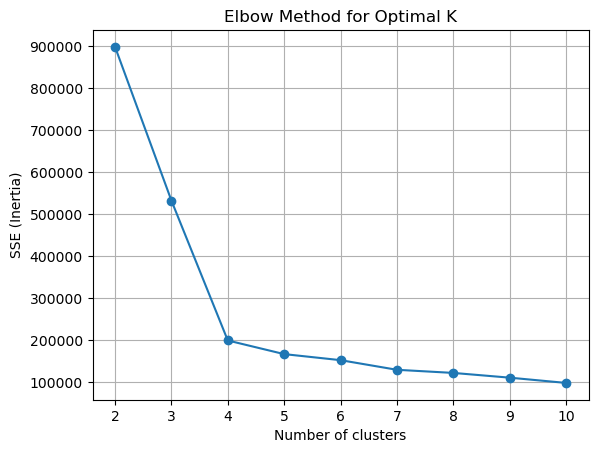

In [22]:
##HeatMaps
# new code

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

# --------------------------
# Step 1: Preprocess for Streets
# --------------------------
df_ML1_cleaned_R1 = df_ML1_cleaned_R1.dropna(subset=['latitude', 'longitude', 'street'])
df_ML1_cleaned_R1['street'] = df_ML1_cleaned_R1['street'].astype(str).str.upper().str.strip()

# --------------------------
# Step 2: Prepare Features for Clustering
# --------------------------
features = ['latitude', 'longitude', 'num_requests', 'request_type_encoded'] + \
           [col for col in df_ML1_cleaned_R1.columns if col.startswith('season_')]

X = df_ML1_cleaned_R1[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------
# Step 3: Elbow Method for Optimal K
# --------------------------
sse = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.plot(K_range, sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()


In [23]:
# set k manually if skipping elbow or from visual
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_ML1_cleaned_R1['cluster'] = kmeans.fit_predict(X_scaled)

# --------------------------
# Step 4: Aggregate by Street & Cluster
# --------------------------
street_clusters = df_ML1_cleaned_R1.groupby(['cluster', 'street']).agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'group_id': 'nunique'  # complaint volume proxy
}).reset_index().rename(columns={'group_id': 'num_complaints'})

# Normalize complaints for heatmap weights
minmax_scaler = MinMaxScaler()
street_clusters['weight'] = minmax_scaler.fit_transform(street_clusters[['num_complaints']])

# Keep only top N streets per cluster
top_n = 300
street_clusters = street_clusters.sort_values(['cluster', 'num_complaints'], ascending=[True, False])
street_clusters = street_clusters.groupby('cluster').head(top_n)
# --------------------------
# Step 5: Heatmap Visualization
# --------------------------
m = folium.Map(
    location=[df_ML1_cleaned_R1['latitude'].mean(), df_ML1_cleaned_R1['longitude'].mean()],
    zoom_start=12
)

for cluster_label in sorted(street_clusters['cluster'].unique()):
    cluster_data = street_clusters[street_clusters['cluster'] == cluster_label]
    
    # Heatmap points
    heat_data = cluster_data[['latitude', 'longitude', 'weight']].values.tolist()
    
    heatmap_layer = folium.FeatureGroup(name=f'Cluster {cluster_label}')
    HeatMap(heat_data, radius=15, blur=20, min_opacity=0.4, max_zoom=14).add_to(heatmap_layer)

    # Top 5 streets with markers
    #top_markers = cluster_data.sort_values('num_complaints', ascending=False).head(5)
    #for _, row in top_markers.iterrows():
        #folium.Marker(
            #location=[row['latitude'], row['longitude']],
            #popup=f"{row['street']} - {int(row['num_complaints'])} complaints",
            #icon=folium.Icon(color="blue", icon="info-sign")
        #).add_to(heatmap_layer)

    heatmap_layer.add_to(m)

folium.LayerControl().add_to(m)

#Legendd
from branca.element import MacroElement
from jinja2 import Template

legend_html = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 200px; height: 140px; 
    background-color: white;
    border:2px solid grey; z-index:9999;
    font-size:14px;
    padding: 10px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
">
<b>Heatmap Legend</b><br>
<span style="background:blue;width:20px;height:10px;display:inline-block;"></span> Low complaints<br>
<span style="background:limegreen;width:20px;height:10px;display:inline-block;"></span> Moderate<br>
<span style="background:yellow;width:20px;height:10px;display:inline-block;"></span> High<br>
<span style="background:red;width:20px;height:10px;display:inline-block;"></span> Very High
</div>

{% endmacro %}
"""

legend = MacroElement()
legend._template = Template(legend_html)
m.get_root().add_child(legend)



# --------------------------
# Save Output
# --------------------------
m.save("Map_C.html")
print("Heatmap saved as: Map_C.html")

Heatmap saved as: Map_C.html


In [24]:
############# MAP A: Heatmap with Noise Filtering #############

# --------------------------
# Step 1: Preprocess for Heatmap
# --------------------------
df_clean = df_ML1_cleaned_R1.dropna(subset=['latitude', 'longitude'])

# Group by location to count unique complaint groups
heat_points = df_clean.groupby(['latitude', 'longitude']).agg({
    'group_id': 'nunique'
}).reset_index().rename(columns={'group_id': 'num_complaints'})

# --------------------------
# Step 2: Filter Out Noise
# --------------------------
# Remove locations with fewer than 5 complaints
heat_points = heat_points[heat_points['num_complaints'] >= 5]

# --------------------------
# Step 3: Normalize with Log Scaling
# --------------------------
heat_points['weight'] = np.log1p(heat_points['num_complaints'])  # log(1 + x)
heat_points['weight'] = MinMaxScaler().fit_transform(heat_points[['weight']])
heat_data = heat_points[['latitude', 'longitude', 'weight']].values.tolist()

# --------------------------
# Step 4: Create High-Contrast Heatmap
# --------------------------
mA = folium.Map(
    location=[df_clean['latitude'].mean(), df_clean['longitude'].mean()],
    zoom_start=12
)

HeatMap(
    heat_data,
    radius=25,         # bigger hotspot radius
    blur=30,           # smooth gradients
    min_opacity=0.4,   # show faint areas too
    max_zoom=14
).add_to(mA)

# --------------------------
# Step 5: Save Output
# --------------------------
mA.save("Map_A_Improved_Filtered_Heatmap.html")
print("Map A saved as: Map_A_Improved_Filtered_Heatmap.html")
####################################################################################


# --------------------------------------------
# MAP B: Top Complaint Streets with Labels
# --------------------------------------------
# Aggregate by street
top_streets = df_clean.groupby('street').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'group_id': 'nunique'
}).reset_index().rename(columns={'group_id': 'num_complaints'})

# Get top 50 streets
top_streets = top_streets.sort_values('num_complaints', ascending=False).head(50)

# Create labeled marker map
mB = folium.Map(
    location=[df_clean['latitude'].mean(), df_clean['longitude'].mean()],
    zoom_start=12
)

for _, row in top_streets.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(f"{row['street']} - {int(row['num_complaints'])} complaints", max_width=250),
        tooltip=row['street'],
        icon=folium.Icon(color="red", icon="exclamation-sign")
    ).add_to(mB)

mB.save("Map_B_Top_Complaint_Streets.html")
print("Map B saved as: Map_B_Top_Complaint_Streets.html")
##################################################

Map A saved as: Map_A_Improved_Filtered_Heatmap.html
Map B saved as: Map_B_Top_Complaint_Streets.html


In [25]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, df_ML1_cleaned_R1['cluster'])

0.7165137687998094

In [26]:
# This interactive map visualizes the geographic distribution and intensity of pothole-related 311 service requests in Pittsburgh, grouped 
# by street-level complaint clusters. It helps identify problematic streets where potholes are reported most frequently and groups 
# them into data-driven clusters for smarter, proactive road maintenance.

### Component 2: Repeat Complaint Zone Modeling for Focused Intervention

In [27]:
df = pd.read_csv('311Data_PotholesOnly.csv')

cols = ['cross_street_id', 
    'request_type_name',  
    'create_date_et']

df = df[cols]

df['create_date_et'] = pd.to_datetime(df['create_date_et'])

In [28]:
#remove cross street ids that are = 0, not a valid location
df = df[(df['cross_street_id'] != 0)]

df = df.dropna()

In [29]:
from pandas.tseries.offsets import Day
import pandas as pd

#convert to proper date time format
df['create_date_et'] = pd.to_datetime(df['create_date_et'])
df = df.sort_values(by='create_date_et')

#add new features, number of repeat complaints and binary 0/1 if a request has been made for a third+ time in the past 30 days
df['num_repeat_complaints'] = 0
df['multiple_repeats'] = 0  

#group by street and request type
#keeping request type in groupby allows model to be used for non-pothole requests if wanted
for (street, req_type), group in df.groupby(['cross_street_id', 'request_type_name']):
    group = group.copy()
    group = group.sort_values('create_date_et')
    repeat_counts = []

    for i in range(len(group)):
        current_time = group.iloc[i]['create_date_et']
        # Look at prior complaints within 30 days
        prior_requests = group.iloc[:i]
        count = (
            (prior_requests['create_date_et'] >= current_time - Day(30))
        ).sum()
        repeat_counts.append(count)

    #update the count of the number of repeats
    df.loc[group.index, 'num_repeat_complaints'] = repeat_counts

#determine if there have already been more than 2 repeat complaints
df['multiple_repeats'] = (df['num_repeat_complaints'] >= 2).astype(int)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 1}
Accuracy: 0.7960115329168669
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.87      3401
           1       0.47      0.78      0.58       761

    accuracy                           0.80      4162
   macro avg       0.70      0.79      0.72      4162
weighted avg       0.85      0.80      0.81      4162



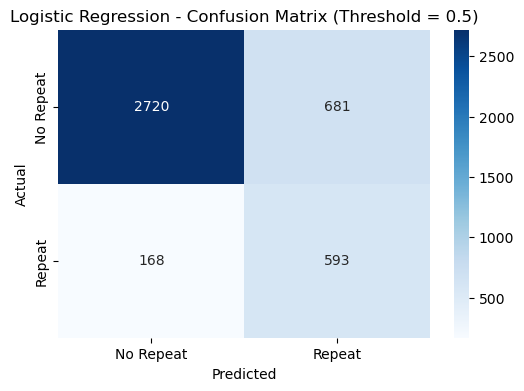

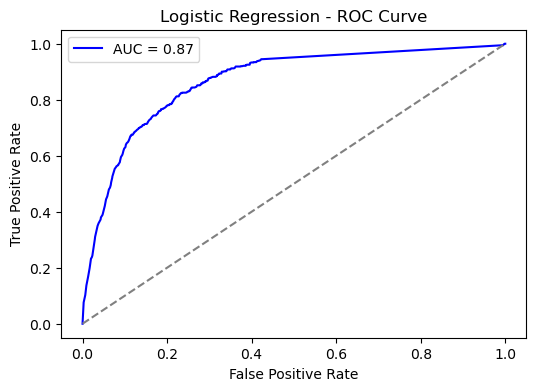

['preprocessor.pkl']

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
import joblib

warnings.filterwarnings("ignore")

#split x and y
X = df.drop(columns=['num_repeat_complaints', 'multiple_repeats', 'create_date_et'])
y = df['multiple_repeats']
categorical_cols = ['cross_street_id', 'request_type_name']


#pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough'
)

#train and test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#preprocessing 
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)


#training the model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
search = RandomizedSearchCV(
    log_reg, param_grid, cv=3, n_iter=8,
    scoring='roc_auc', n_jobs=-1, verbose=1
)
search.fit(X_train_transformed, y_train)
final_model = search.best_estimator_


y_pred = final_model.predict(X_val_transformed)
y_proba = final_model.predict_proba(X_val_transformed)[:, 1]  # still useful for AUC/ROC

#output metrics
print("Best Parameters:", search.best_params_)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

#output confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Repeat', 'Repeat'],
            yticklabels=['No Repeat', 'Repeat'])
plt.title("Logistic Regression - Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#output AUC plot
fpr, tpr, _ = roc_curve(y_val, y_proba)
auc_score = roc_auc_score(y_val, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#saving the final model
joblib.dump(final_model, 'final_logistic_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

In [31]:
#example of using the model

#input the request type and cross street id to make a prediction
new_request = pd.DataFrame([{
    'cross_street_id': 3723.0,
    'request_type_name': 'Pothole',
}])
#using the model's preprocessor
new_request_processed = preprocessor.transform(new_request)

#find the probability with the model
prob = final_model.predict_proba(new_request_processed)[0][1] 
prediction = int(prob >= 0.50) 

#output results from the model
print(f"Probability of repeat complaint: {prob:.2f}")
print("Predicted label:", "Repeat" if prediction == 1 else "Not a repeat")

Probability of repeat complaint: 0.98
Predicted label: Repeat


### Component 3: Forecasting Departmental Workload for Resource Allocation

In [32]:
# 1) Imports & load
import pandas as pd
import numpy as np

# read CSV
df = pd.read_csv('311Data_PotholesOnly.csv')

# Filter rows where 'request_type_name' contains 'pothole' (case-insensitive)
#df = df[df['request_type_name'].str.contains('pothole', case=False, na=False)]


In [33]:
# 2) Cyclical & rolling feature engineering

# ensure datetime
df['create_date_et'] = pd.to_datetime(df['create_date_et'])

# helper to add sin/cos columns
def encode_cyclical_feature(df, col):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / df[col].max())
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / df[col].max())

# extract basic time features
df['Month']  = df['create_date_et'].dt.month
df['Week']   = df['create_date_et'].dt.isocalendar().week
df['Season'] = df['create_date_et'].dt.month % 12 // 3 + 1

# apply cyclical encoding
encode_cyclical_feature(df, 'Month')
encode_cyclical_feature(df, 'Week')
encode_cyclical_feature(df, 'Season')

# weekly aggregation
df['YearWeek'] = df['create_date_et'].dt.strftime('%Y-%U')
weekly_data = (
    df
    .groupby(['YearWeek','dept','request_type_name','neighborhood'])
    .size()
    .reset_index(name='request_count')
)

# sort for lags
weekly_data = weekly_data.sort_values(
    ['dept','request_type_name','neighborhood','YearWeek']
)

# create 4 lag features
for lag in range(1,5):
    weekly_data[f'lag_{lag}'] = (
        weekly_data
        .groupby(['dept','request_type_name','neighborhood'])['request_count']
        .shift(lag)
    )

# 4‑week moving average
weekly_data['moving_avg_4'] = (
    weekly_data
    .groupby(['dept','request_type_name','neighborhood'])['request_count']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# bring back the cyclical columns by YearWeek
cyc = ['YearWeek',
       'Month_sin','Month_cos',
       'Week_sin','Week_cos',
       'Season_sin','Season_cos']
weekly_data = weekly_data.merge(
    df[cyc].drop_duplicates(),
    on='YearWeek', how='left'
)

# drop any rows still containing NaNs
weekly_data = weekly_data.dropna()

In [34]:
# 3) Prepare X, y and train/test split

# define feature list

feature_cols = [
    'dept', 'request_type_name', 'neighborhood',
    'Month_sin','Month_cos',
    'Week_sin','Week_cos',
    'Season_sin','Season_cos',
    'lag_1','lag_2','lag_3','lag_4',
    'moving_avg_4'
]

X = weekly_data[feature_cols]
y = weekly_data['request_count']

# 3b) Per‑group temporal split (80/20 within each series)

# compute each group’s size and each row’s position
group_cols = ['dept','request_type_name','neighborhood']
weekly_data['group_size'] = (
    weekly_data
    .groupby(group_cols)['request_count']
    .transform('size')
)
weekly_data['group_idx'] = (
    weekly_data
    .groupby(group_cols)
    .cumcount()
)

# compute the 80% cutoff index
weekly_data['cutoff'] = (weekly_data['group_size'] * 0.8).astype(int)

# label each row as train or test
weekly_data['_set'] = np.where(
    weekly_data['group_idx'] < weekly_data['cutoff'],
    'train', 'test'
)

# split out train and test DataFrames
train = weekly_data[weekly_data['_set']=='train']
test  = weekly_data[weekly_data['_set']=='test']

# build X_train, y_train, X_test, y_test
X_train = train[feature_cols]
y_train = train['request_count']
X_test  = test[feature_cols]
y_test  = test['request_count']

# clean up helper columns
weekly_data.drop(
    ['group_size','group_idx','cutoff','_set'],
    axis=1, inplace=True
)


In [35]:
# 4) Build preprocessing + model pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# identify categorical vs numeric
cat_feats = ['dept','request_type_name','neighborhood']
num_feats = [c for c in X_train.columns if c not in cat_feats]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats),
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1
    ))
])


In [36]:
# 5) Train, predict & evaluate

# fit
pipeline.fit(X_train, y_train)

# predict
y_pred = pipeline.predict(X_test)

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')


MSE:  0.0617
RMSE: 0.2483
MAE:  0.1516
R2:   0.9794


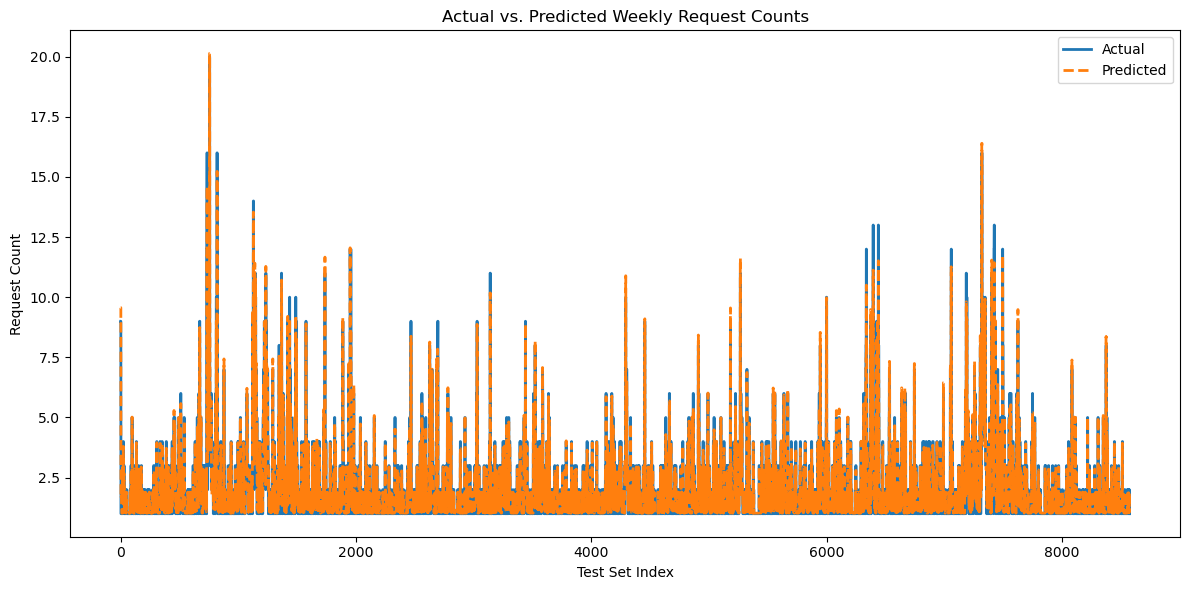

In [37]:
# 6) Plot actual vs. predicted request counts
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Weekly Request Counts')
plt.xlabel('Test Set Index')
plt.ylabel('Request Count')
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
# 7) Forecast next N future weeks for each series

import pandas as pd

# how many weeks you want to predict into the future
N = 1

# ── A) Turn your existing YearWeek string into a real date (Sunday of that week) ──
weekly_data['YearWeek_dt'] = pd.to_datetime(
    weekly_data['YearWeek'] + '-0',  # '-0' means Sunday
    format='%Y-%U-%w'
)

# find the last known week and build a list of the next N Sundays
last_dt = weekly_data['YearWeek_dt'].max()
future_dates = [last_dt + pd.Timedelta(weeks=i+1) for i in range(N)]

# convert those back into the same 'YYYY-ww' format
future_weeks = [d.strftime('%Y-%U') for d in future_dates]

# ── B) Build a DataFrame with one row per (future_week × dept × type × neighborhood) ──
groups = (
    weekly_data
    .loc[:, ['dept','request_type_name','neighborhood']]
    .drop_duplicates()
)
future = (
    pd.MultiIndex
      .from_product([future_weeks,
                     groups['dept'],
                     groups['request_type_name'],
                     groups['neighborhood']],
                    names=['YearWeek','dept','request_type_name','neighborhood'])
      .to_frame(index=False)
)

# ── C) Recompute your cyclical time features on these future weeks ──
future['YearWeek_dt'] = pd.to_datetime(
    future['YearWeek'] + '-0', format='%Y-%U-%w'
)
future['Month']  = future['YearWeek_dt'].dt.month
future['Week']   = future['YearWeek_dt'].dt.isocalendar().week
future['Season'] = future['Month'] % 12 // 3 + 1

encode_cyclical_feature(future, 'Month')
encode_cyclical_feature(future, 'Week')
encode_cyclical_feature(future, 'Season')

# ── D) Pull in the last 4 known request_counts as lags ──
for lag in range(1,5):
    # get one row per group with the lag-th last value
    prev = (
        weekly_data
        .groupby(['dept','request_type_name','neighborhood'])['request_count']
        .apply(lambda x: x.iloc[-lag])
        .reset_index(name=f'lag_{lag}')
    )
    future = future.merge(prev,
                          on=['dept','request_type_name','neighborhood'],
                          how='left')

# ── E) Compute the 4‑week moving average over the last 4 known weeks ──
mov = (
    weekly_data
    .groupby(['dept','request_type_name','neighborhood'])['request_count']
    .apply(lambda x: x.iloc[-4:].mean())
    .reset_index(name='moving_avg_4')
)
future = future.merge(mov,
                      on=['dept','request_type_name','neighborhood'],
                      how='left')

In [39]:
# 8) Finally, predict! ──

# specify the neighborhood you want to inspect
# Examples: "Shadyside", "Squirrel Hill South", "Upper Lawrenceville", "Bloomfield"
neighborhood_of_interest = "Bloomfield"

X_future = future[feature_cols]
future['prediction'] = pipeline.predict(X_future)

# filter the future DataFrame
future_subset = future[future['neighborhood'] == neighborhood_of_interest]

# drop fully identical duplicate rows and set index
future_unique = future_subset.drop_duplicates()
future_unique = future_unique.set_index('YearWeek')

# display only the columns you care about
print(future_unique[['neighborhood',
                   'dept',
                   'request_type_name',
                   'prediction']])

         neighborhood                      dept request_type_name  prediction
YearWeek                                                                     
2025-06    Bloomfield  DPW - Street Maintenance          Potholes   17.509151
